In [67]:
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [68]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

x = torch.randn(2,2).to('cuda')
print("Tensor on GPU:", x)

CUDA available: True
CUDA version: 12.1
Tensor on GPU: tensor([[-0.2378,  1.0156],
        [-0.9223, -0.2199]], device='cuda:0')


In [69]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [70]:
print("length of dataset in characters: ", len(text))

length of dataset in characters:  1115393


In [71]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


In [72]:
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

print(encode("hii there"))
print(decode(encode("hii there")))

[46, 47, 47, 1, 58, 46, 43, 56, 43]
hii there


In [73]:
# let's now encode the entire text dataset and store it into a torch.Tensor
import torch # we use PyTorch: https://pytorch.org
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:1000]) # the 1000 characters we looked at earier will to the GPT look like this

torch.Size([1115393]) torch.int64
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 57, 53, 50, 60, 43, 42,
         8,  1, 56, 43, 57, 53, 50, 60, 43, 42,  8,  0,  0, 18, 47, 56, 57, 58,
         1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 18, 47, 56, 57, 58,  6,  1, 63,
        53, 59,  1, 49, 52, 53, 61,  1, 15, 39, 47, 59, 57,  1, 25, 39, 56, 41,
      

In [74]:
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

In [75]:
block_size = 8
train_data[:block_size+1]

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58])

In [76]:
x = train_data[:block_size]
y = train_data[1:block_size+1]
for t in range(block_size):
    context = x[:t+1]
    target = y[t]
    print(f"when input is {context} the target: {target}")

when input is tensor([18]) the target: 47
when input is tensor([18, 47]) the target: 56
when input is tensor([18, 47, 56]) the target: 57
when input is tensor([18, 47, 56, 57]) the target: 58
when input is tensor([18, 47, 56, 57, 58]) the target: 1
when input is tensor([18, 47, 56, 57, 58,  1]) the target: 15
when input is tensor([18, 47, 56, 57, 58,  1, 15]) the target: 47
when input is tensor([18, 47, 56, 57, 58,  1, 15, 47]) the target: 58


In [77]:
torch.manual_seed(1337)
batch_size = 4 # how many independent sequences will we process in parallel?
block_size = 8 # what is the maximum context length for predictions?

def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

print('----')

for b in range(batch_size): # batch dimension
    for t in range(block_size): # time dimension
        context = xb[b, :t+1]
        target = yb[b,t]
        print(f"when input is {context.tolist()} the target: {target}")

inputs:
torch.Size([4, 8])
tensor([[53, 59,  6,  1, 58, 56, 47, 40],
        [49, 43, 43, 54,  1, 47, 58,  1],
        [13, 52, 45, 43, 50, 53,  8,  0],
        [ 1, 39,  1, 46, 53, 59, 57, 43]], device='cuda:0')
targets:
torch.Size([4, 8])
tensor([[59,  6,  1, 58, 56, 47, 40, 59],
        [43, 43, 54,  1, 47, 58,  1, 58],
        [52, 45, 43, 50, 53,  8,  0, 26],
        [39,  1, 46, 53, 59, 57, 43,  0]], device='cuda:0')
----
when input is [53] the target: 59
when input is [53, 59] the target: 6
when input is [53, 59, 6] the target: 1
when input is [53, 59, 6, 1] the target: 58
when input is [53, 59, 6, 1, 58] the target: 56
when input is [53, 59, 6, 1, 58, 56] the target: 47
when input is [53, 59, 6, 1, 58, 56, 47] the target: 40
when input is [53, 59, 6, 1, 58, 56, 47, 40] the target: 59
when input is [49] the target: 43
when input is [49, 43] the target: 43
when input is [49, 43, 43] the target: 54
when input is [49, 43, 43, 54] the target: 1
when input is [49, 43, 43, 54, 1] the 

In [78]:
print(xb)

tensor([[53, 59,  6,  1, 58, 56, 47, 40],
        [49, 43, 43, 54,  1, 47, 58,  1],
        [13, 52, 45, 43, 50, 53,  8,  0],
        [ 1, 39,  1, 46, 53, 59, 57, 43]], device='cuda:0')


In [79]:
eval_iters = 200

### BIGRAM LANG MODEL

In [80]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)
n_embd = 32

class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B,T = idx.shape
        # idx and targets are both (B,T) tensor of integers
        token_embeddings = self.token_embedding_table(idx) # (B,T,C)
        position_embeddings = self.position_embedding_table(torch.arange(T, device=idx.device)) # (T,C)
        x = token_embeddings + position_embeddings # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B,T,C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss
    
    # def generate(self, idx, max_new_tokens):
    #     # idx is (B,T) array of indices in the current context
    #     for _ in range(max_new_tokens):
    #         logits, loss = self(idx) # (B,T,C)
    #         logits = logits[:, -1, :] # becomes (B,C)
    #         probs = F.softmax(logits, dim=-1) # (B,C)
    #         idx_next = torch.multinomial(probs, num_samples=1) # (B,1)
    #         idx = torch.cat((idx, idx_next), dim=1) # append to the running sequence (B,T+1)
    #     return idx
    def generate(self, idx, max_new_tokens):
        #idx is (B,T) array of indices in the current context
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]   
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] #B,C
            probs = F.softmax(logits, dim=-1) #becomes (B,C)
            idx_next = torch.multinomial(probs, num_samples=1) #(B,1)
            idx = torch.cat((idx, idx_next), dim=1) #append to the running sequence (B,T+1)
        return idx

In [81]:
vocab_size = len(chars)
model = BigramLanguageModel(vocab_size)
m = model.to(device)
logits, loss = m(xb, yb)
print("logits shape: ", logits.shape)
print("loss: ", loss)

logits shape:  torch.Size([32, 65])
loss:  tensor(4.3152, device='cuda:0', grad_fn=<NllLossBackward0>)


In [82]:
print(decode(m.generate(idx=torch.zeros((1,1), dtype=torch.long).to(device), max_new_tokens=100)[0].tolist()))


?YCnx.DkRZ'Ndc.wd,ZTkOUlT-yHtK
b:!PTCNMBbzAU3:XaSvgO-33mMGd?gL3auhX:YVXhthXNNuyqcBMxv.tbfr3dXlrSZaAe


In [83]:
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

In [84]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [85]:
batch_size = 32
for steps in range(3000):
    if steps % 100 == 0:
        losses = estimate_loss()
        print(f"step {steps}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}") 
    xb, yb = get_batch('train')

    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())

step 0: train loss 4.4788, val loss 4.4801
step 100: train loss 3.3994, val loss 3.4215
step 200: train loss 3.0447, val loss 3.0557
step 300: train loss 2.8724, val loss 2.9150
step 400: train loss 2.7808, val loss 2.8097
step 500: train loss 2.7404, val loss 2.7596
step 600: train loss 2.6882, val loss 2.7071
step 700: train loss 2.6530, val loss 2.6785
step 800: train loss 2.6383, val loss 2.6632
step 900: train loss 2.6143, val loss 2.6330
step 1000: train loss 2.6014, val loss 2.6066
step 1100: train loss 2.5822, val loss 2.6013
step 1200: train loss 2.5571, val loss 2.5833
step 1300: train loss 2.5497, val loss 2.5720
step 1400: train loss 2.5392, val loss 2.5657
step 1500: train loss 2.5431, val loss 2.5579
step 1600: train loss 2.5367, val loss 2.5486
step 1700: train loss 2.5288, val loss 2.5396
step 1800: train loss 2.5324, val loss 2.5492
step 1900: train loss 2.5208, val loss 2.5372
step 2000: train loss 2.5199, val loss 2.5383
step 2100: train loss 2.5167, val loss 2.5182


In [86]:
print(decode(m.generate(idx=torch.zeros((1,1), dtype=torch.long).to(device), max_new_tokens=200)[0].tolist()))


Wawice my.
Whastarom oroup
Yowhthetof isth ble mil ndill, aes iree sengcin lat Herid ov ts, anend l nghirileranousel lind pe llllishe ce hiry:
Supr aisspllw y.
Hllindu n Boupetelaves
Momy y wod mothak


## SELF ATTENTION

### CREATING THE SELF ATTENTION CLASS (REFER TO selfattention.ipynb)

In [87]:
class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)   # (B,T,head_size)
        q = self.query(x) # (B,T,head_size)
        v = self.value(x) # (B,T,head_size)

        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B,T,head_size) @ (B,head_size,T) -> (B,T,T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B,T,T)
        wei = F.softmax(wei, dim=-1) # (B,T,T)
        out = wei @ v # (B,T,T) @ (B,T,head_size) -> (B,T,head_size)
        return out

In [88]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd) #block size is the maximum context length for predictions, we can use it to index into the position embedding table
        self.sa_head = Head(n_embd) #self attention head
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B,T = idx.shape
        # idx and targets are both (B,T) tensor of integers
        token_embeddings = self.token_embedding_table(idx) # (B,T,C)
        position_embeddings = self.position_embedding_table(torch.arange(T, device=idx.device)) # (T,C)
        x = token_embeddings + position_embeddings # (B,T,C)
        x = self.sa_head(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B,T,C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)
    
    def generate(self, idx, max_new_tokens):
        #idx is (B,T) array of indices in the current context
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]   #crop to the last block_size tokens
            logits, _ = self(idx_cond) #get the predictions
            # focus only on the last time step
            logits = logits[:, -1, :] #B,C
            probs = F.softmax(logits, dim=-1) #becomes (B,C)
            idx_next = torch.multinomial(probs, num_samples=1) #(B,1)
            idx = torch.cat((idx, idx_next), dim=1) #append to the running sequence (B,T+1)

        return logits, loss

In [89]:
batch_size = 32
block_size = 8
max_iters = 5000
eval_interval = 500
learning_rate = 1e-3
eval_iters = 200
n_embd = 32

In [90]:
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

In [ ]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = m(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [92]:
for steps in range(max_iters):
    if steps % eval_interval == 0:
        losses = estimate_loss()
        print(f"step {steps}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}") 
    xb, yb = get_batch('train')

    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())

step 0: train loss 2.4969, val loss 2.5096
step 500: train loss 2.4918, val loss 2.5053
step 1000: train loss 2.4907, val loss 2.4997
step 1500: train loss 2.4907, val loss 2.4965
step 2000: train loss 2.4739, val loss 2.4953
step 2500: train loss 2.4842, val loss 2.5056
step 3000: train loss 2.4744, val loss 2.4899
step 3500: train loss 2.4700, val loss 2.4962
step 4000: train loss 2.4821, val loss 2.4967
step 4500: train loss 2.4625, val loss 2.5007
2.4993960857391357


## MULTIHEAD ATTENTION

In [131]:
class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return out

In [132]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd) #block size is the maximum context length for predictions, we can use it to index into the position embedding table
        self.sa_heads = MultiHeadAttention(num_heads=4, head_size=n_embd//4) #self attention head # 4 * n_embd//4 = n_embd
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B,T = idx.shape
        # idx and targets are both (B,T) tensor of integers
        token_embeddings = self.token_embedding_table(idx) # (B,T,C)
        position_embeddings = self.position_embedding_table(torch.arange(T, device=idx.device)) # (T,C)
        x = token_embeddings + position_embeddings # (B,T,C)
        x = self.sa_heads(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B,T,C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss
    
    def generate(self, idx, max_new_tokens):
        #idx is (B,T) array of indices in the current context
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]   #crop to the last block_size tokens
            logits, _ = self(idx_cond) #get the predictions
            # focus only on the last time step
            logits = logits[:, -1, :] #B,C
            probs = F.softmax(logits, dim=-1) #becomes (B,C)
            idx_next = torch.multinomial(probs, num_samples=1) #(B,1)
            idx = torch.cat((idx, idx_next), dim=1) #append to the running sequence (B,T+1)

        return idx

In [133]:
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = m(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [134]:
for steps in range(max_iters):
    if steps % eval_interval == 0:
        losses = estimate_loss()
        print(f"step {steps}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}") 
    xb, yb = get_batch('train')

    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())

step 0: train loss 2.0749, val loss 2.1641
step 500: train loss 2.0652, val loss 2.1498
step 1000: train loss 2.0703, val loss 2.1511
step 1500: train loss 2.0655, val loss 2.1509
step 2000: train loss 2.0678, val loss 2.1357
step 2500: train loss 2.0638, val loss 2.1428
step 3000: train loss 2.0617, val loss 2.1596
step 3500: train loss 2.0699, val loss 2.1529
step 4000: train loss 2.0581, val loss 2.1572
step 4500: train loss 2.0632, val loss 2.1449
2.039797067642212


### INTRODUCING FEEDFORWARD NETWORK 
### SA -> FFN (PER TOKEN LEVEL) -> LOGITS CREATION

In [135]:
class FeedForward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, n_embd),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)

In [136]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd) #block size is the maximum context length for predictions, we can use it to index into the position embedding table
        self.sa_heads = MultiHeadAttention(num_heads=4, head_size=n_embd//4) #self attention head # 4 * n_embd//4 = n_embd
        self.ffwd = FeedForward(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B,T = idx.shape
        # idx and targets are both (B,T) tensor of integers
        token_embeddings = self.token_embedding_table(idx) # (B,T,C)
        position_embeddings = self.position_embedding_table(torch.arange(T, device=idx.device)) # (T,C)
        x = token_embeddings + position_embeddings # (B,T,C)
        x = self.sa_heads(x) # (B,T,C)
        x = self.ffwd(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B,T,C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss
    
    def generate(self, idx, max_new_tokens):
        #idx is (B,T) array of indices in the current context
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]   #crop to the last block_size tokens
            logits, _ = self(idx_cond) #get the predictions
            # focus only on the last time step
            logits = logits[:, -1, :] #B,C
            probs = F.softmax(logits, dim=-1) #becomes (B,C)
            idx_next = torch.multinomial(probs, num_samples=1) #(B,1)
            idx = torch.cat((idx, idx_next), dim=1) #append to the running sequence (B,T+1)

        return idx

In [137]:
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = m(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

for steps in range(max_iters):
    if steps % eval_interval == 0:
        losses = estimate_loss()
        print(f"step {steps}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}") 
    xb, yb = get_batch('train')

    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())

step 0: train loss 2.0672, val loss 2.1545
step 500: train loss 2.0641, val loss 2.1584
step 1000: train loss 2.0628, val loss 2.1457
step 1500: train loss 2.0621, val loss 2.1498
step 2000: train loss 2.0517, val loss 2.1396
step 2500: train loss 2.0574, val loss 2.1371
step 3000: train loss 2.0476, val loss 2.1551
step 3500: train loss 2.0491, val loss 2.1504
step 4000: train loss 2.0610, val loss 2.1409
step 4500: train loss 2.0433, val loss 2.1463
1.9581090211868286


#### ADDING THE TRANSFORMER BLOCK FOR "INTERSPERSING" THE OPERATIONS "COMMUNICATION" (MULTIHEAD ATTENTION) AND "COMPUTATION" (FFN)

In [138]:
class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa_heads = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)

    def forward(self, x):
        x = self.sa_heads(x)
        x = self.ffwd(x)
        return x

In [139]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd) #block size is the maximum context length for predictions, we can use it to index into the position embedding table
        # self.sa_heads = MultiHeadAttention(num_heads=4, head_size=n_embd//4) #self attention head # 4 * n_embd//4 = n_embd
        # self.ffwd = FeedForward(n_embd)
        # self.lm_head = nn.Linear(n_embd, vocab_size)
        self.blocks = nn.Sequential(
            Block(n_embd, n_head=4),
            Block(n_embd, n_head=4),
            Block(n_embd, n_head=4),
        )

    def forward(self, idx, targets=None):
        B,T = idx.shape
        # idx and targets are both (B,T) tensor of integers
        token_embeddings = self.token_embedding_table(idx) # (B,T,C)
        position_embeddings = self.position_embedding_table(torch.arange(T, device=idx.device)) # (T,C)
        x = token_embeddings + position_embeddings # (B,T,C)
        # x = self.sa_heads(x) # (B,T,C)
        # x = self.ffwd(x) # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B,T,C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)
    
    def generate(self, idx, max_new_tokens):
        #idx is (B,T) array of indices in the current context
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]   #crop to the last block_size tokens
            logits, _ = self(idx_cond) #get the predictions
            # focus only on the last time step
            logits = logits[:, -1, :] #B,C
            probs = F.softmax(logits, dim=-1) #becomes (B,C)
            idx_next = torch.multinomial(probs, num_samples=1) #(B,1)
            idx = torch.cat((idx, idx_next), dim=1) #append to the running sequence (B,T+1)

        return logits, loss

In [140]:
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = m(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

for steps in range(max_iters):
    if steps % eval_interval == 0:
        losses = estimate_loss()
        print(f"step {steps}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}") 
    xb, yb = get_batch('train')

    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())

step 0: train loss 2.0651, val loss 2.1429
step 500: train loss 2.0522, val loss 2.1376
step 1000: train loss 2.0498, val loss 2.1386
step 1500: train loss 2.0490, val loss 2.1454
step 2000: train loss 2.0541, val loss 2.1381
step 2500: train loss 2.0671, val loss 2.1489
step 3000: train loss 2.0367, val loss 2.1355
step 3500: train loss 2.0310, val loss 2.1425
step 4000: train loss 2.0441, val loss 2.1418
step 4500: train loss 2.0435, val loss 2.1400
2.0639901161193848


### RESIDUAL CONNECTIONS

##### WHAT HAPPENED BEFORE WAS, THE NEURAL NETWORK BECAME SO DENSE (DEEP NEURAL NET), THUS MAKING COMPUTATION VERY HEAVY, TO SOLVE THIS RESIDUAL CONNECTIONS WERE INTRODUCED

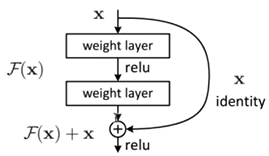

In [141]:
class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa_heads = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)

    def forward(self, x):
        x = x + self.sa_heads(x)
        x = x + self.ffwd(x)
        return x

### USING PROJECTION INSTEAD OF SIMPLY CONCATINATING OUTPUTS OF MULTIHEAD

In [142]:
class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        return out

In [143]:
class FeedForward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd)
        )

    def forward(self, x):
        return self.net(x)

In [144]:
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = m(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

for steps in range(max_iters):
    if steps % eval_interval == 0:
        losses = estimate_loss()
        print(f"step {steps}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}") 
    xb, yb = get_batch('train')

    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())

step 0: train loss 2.0499, val loss 2.1415
step 500: train loss 2.0396, val loss 2.1502
step 1000: train loss 2.0490, val loss 2.1396
step 1500: train loss 2.0536, val loss 2.1369
step 2000: train loss 2.0370, val loss 2.1354
step 2500: train loss 2.0348, val loss 2.1336
step 3000: train loss 2.0410, val loss 2.1348
step 3500: train loss 2.0367, val loss 2.1351
step 4000: train loss 2.0472, val loss 2.1415
step 4500: train loss 2.0275, val loss 2.1418
2.0676798820495605


In [145]:
print(decode(m.generate(idx=torch.zeros((1,1), dtype=torch.long).to(device), max_new_tokens=300)[0].tolist()))


Prove liveses tway,
And ofen: the wifly,
But fat are Edmry, ive! wito amonge,
Aong? Aa hereat repese yon'd,
Thas conot,
What the o'erower like he pusich gunks to the a of the nath.

Gursedury promble me,
I LELLO:
Witan daus no's tho, Jill Repatfiell brifors men'ed.

MARKENIO:
So offer henixe!


MEPL


### LAYER NORMALIZATION